In [1]:
import numpy as np
from PIL import ImageFont
from modules.palette_generation import get_asciis, make_symbol2value_map
from matplotlib import pyplot as plt
from statistics import mean

In [2]:
FONT = ImageFont.truetype("../fonts/CascadiaMono.ttf", 11)
SYMBOLS = get_asciis()

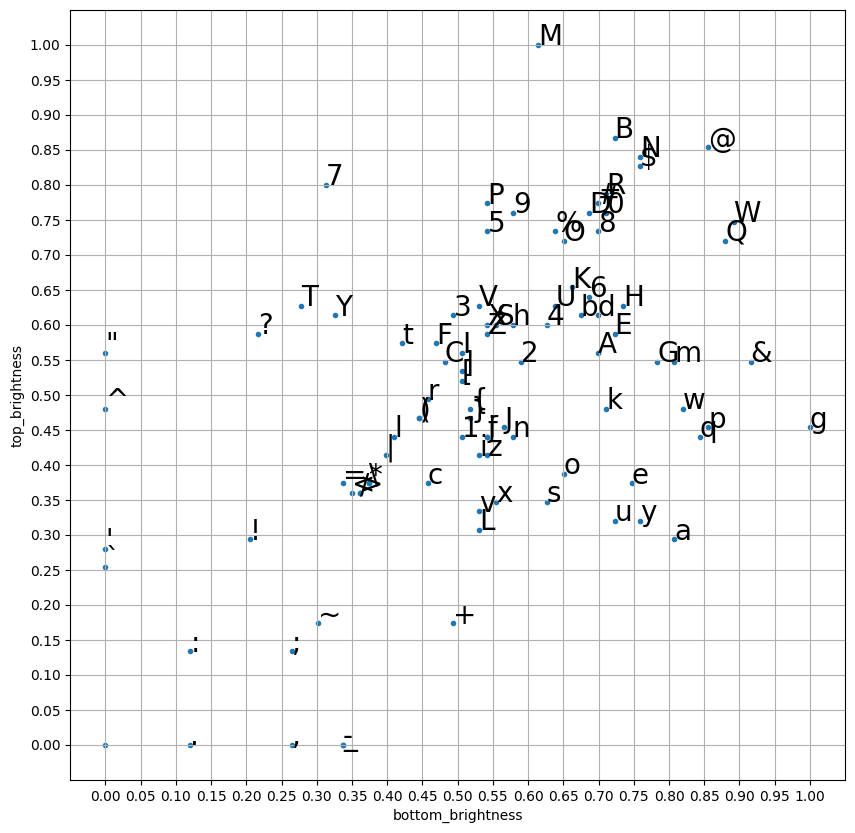

In [3]:
symbol2brightness = make_symbol2value_map(
    symbols=SYMBOLS,
    font=FONT,
    val_height=2,
    val_width=1,
    normalize=True)

brightness = list(symbol2brightness.values())
top_brightness = [b[0][0] for b in brightness]
bottom_brightness = [b[1][0] for b in brightness]

plt.figure(figsize=(10, 10))
plt.scatter(bottom_brightness, top_brightness, marker='.')
plt.xticks(np.arange(0.0, max(bottom_brightness) + 0.05, 0.05))
plt.yticks(np.arange(0.0, max(top_brightness) + 0.05, 0.05))
plt.xlabel("bottom_brightness")
plt.ylabel("top_brightness")
for s, btm_br, top_br in zip(SYMBOLS, bottom_brightness, top_brightness):
    plt.annotate(s, (btm_br, top_br), size=20)
plt.grid()

In [4]:
from modules.img2chars_2d_bin import make_2d_bin_palette
bins, mean_bin_brs = make_2d_bin_palette(SYMBOLS, FONT, (9, 9), normalize=True)
for row in bins:
    print(row)

[[' '], ['.'], [',', '-', '_'], ['-'], ['-'], ['-'], ['-'], ['-'], ['-']]
[[' '], [':'], [';', '~'], ['~'], ['+'], ['+'], ['+'], ['+'], ['+']]
[["'", '`'], ['!'], ['!'], ['!'], ['v', 'L'], ['v'], ['u', 'y'], ['a'], ['a']]
[["'"], ['!'], ['='], ['c', 'l', '*', '/', '<', '>', '\\', '|'], ['1', 'i', 'z'], ['f', 'j', 'n', 'o', 's', 'x', 'J'], ['e'], ['p', 'q'], ['g']]
[['"', '^'], ['"'], ['='], ['(', ')'], ['r', 'C', 'I', '[', ']', '{', '}'], ['2'], ['k'], ['m', 'w', 'G'], ['&']]
[['"'], ['"'], ['T', 'Y', '?'], ['t'], ['3', 'F', 'V', 'Z'], ['4', 'h', 'S', 'U', 'X'], ['6', 'b', 'd', 'A', 'E', 'H', 'K'], ['K'], ['&']]
[['"'], ['"'], ['Y'], ['t'], ['V'], ['5', '9', 'O', 'P', '%'], ['0', '8', 'D', '#'], ['Q', 'W'], ['W']]
[['"'], ['"'], ['7'], ['7'], ['V'], ['O'], ['B', 'N', 'R', '$'], ['@'], ['@']]
[['"'], ['"'], ['7'], ['7'], ['V'], ['M'], ['M'], ['@'], ['@']]


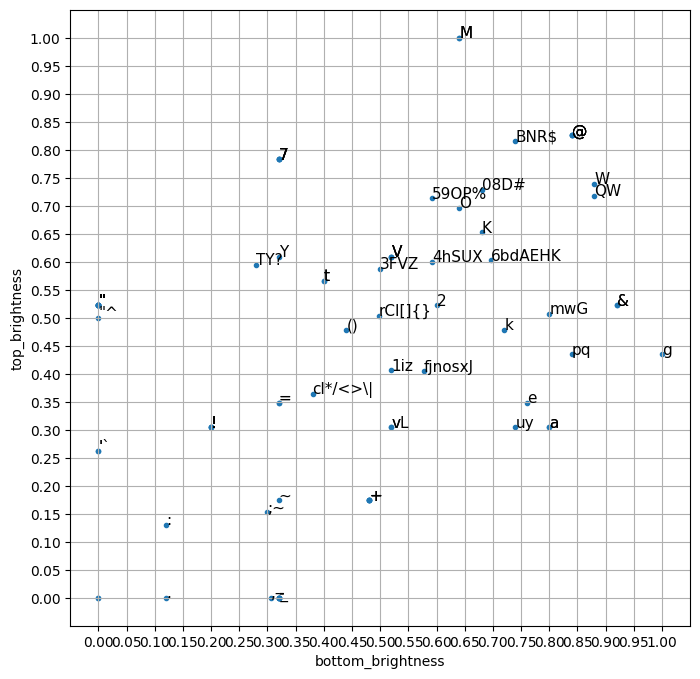

In [5]:
flat_bins = []
flat_mean_bins = []
for row in range(len(bins)):
    for col in range(len(bins[row])):
        flat_bins.append(''.join(bins[row][col]))
        flat_mean_bins.append(mean_bin_brs[row][col])

top_brightness = [b[0][0] for b in flat_mean_bins]
bottom_brightness = [b[1][0] for b in flat_mean_bins]
plt.figure(figsize=(8, 8))
plt.scatter(bottom_brightness, top_brightness, marker='.')
plt.xticks(np.arange(0.0, max(bottom_brightness) + 0.05, 0.05))
plt.yticks(np.arange(0.0, max(top_brightness) + 0.05, 0.05))
plt.xlabel("bottom_brightness")
plt.ylabel("top_brightness")
for s, btm_br, top_br in zip(flat_bins, bottom_brightness, top_brightness):
    plt.annotate(s, (btm_br, top_br), size=11)
plt.grid()

In [6]:
palette = []
for row in bins:
    palette.append([])
    for bin in row:
        sorted_bin = sorted(bin, key=lambda s: np.mean(symbol2brightness[s]))
        c = sorted_bin[len(sorted_bin)//2]
        palette[-1].append(c)
    print(palette[-1])

[' ', '.', '-', '-', '-', '-', '-', '-', '-']
[' ', ':', '~', '~', '+', '+', '+', '+', '+']
["'", '!', '!', '!', 'v', 'v', 'y', 'a', 'a']
["'", '!', '=', '\\', '1', 'j', 'e', 'p', 'g']
['"', '"', '=', ')', '[', '2', 'k', 'G', '&']
['"', '"', 'T', 't', 'Z', 'h', 'd', 'K', '&']
['"', '"', 'Y', 't', 'V', '9', '0', 'W', 'W']
['"', '"', '7', '7', 'V', 'O', 'B', '@', '@']
['"', '"', '7', '7', 'V', 'M', 'M', '@', '@']


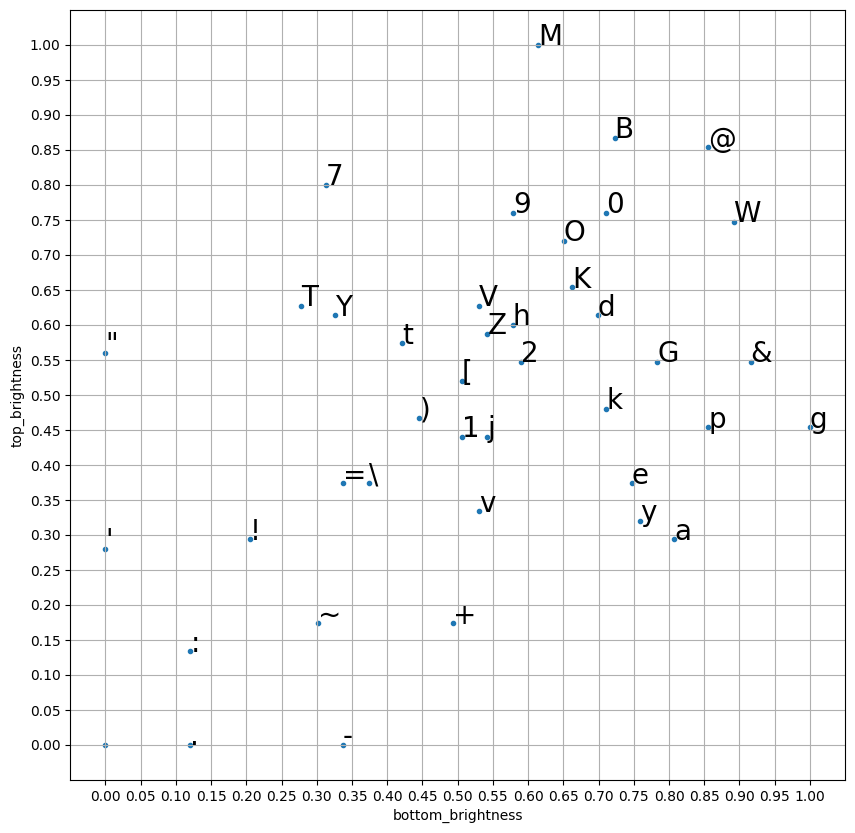

In [7]:
palette_chars = np.unique(palette)

s2b = {s: symbol2brightness[s] for s in palette_chars}
brightness = s2b.values()
top_brightness = [b[0][0] for b in brightness]
bottom_brightness = [b[1][0] for b in brightness]
plt.figure(figsize=(10, 10))
plt.scatter(bottom_brightness, top_brightness, marker='.')
plt.xticks(np.arange(min(bottom_brightness), max(bottom_brightness) + 0.05, 0.05))
plt.yticks(np.arange(min(top_brightness), max(top_brightness) + 0.05, 0.05))
plt.xlabel("bottom_brightness")
plt.ylabel("top_brightness")
for row in range(len(palette_chars)):
    plt.annotate(palette_chars[row], (bottom_brightness[row], top_brightness[row]), size=20)
plt.grid()